# Gravity-Dominated CO₂ Storage and the Limits of Agreement in the SPE11b Benchmark

**Daniel Olagunju · Universiti Teknologi PETRONAS (UTP)**

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/todak2000/co2-heterogeneity-screening/HEAD?labpath=heterogeneity_screening.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/todak2000/co2-heterogeneity-screening/blob/main/heterogeneity_screening.ipynb)

This notebook reproduces, end-to-end and with no hidden constants, the results of the companion paper. It characterises the SPE11b CO₂ storage benchmark on three axes:

1. **Its dimensionless flow regime** (aspect ratio, effective aspect ratio, buoyancy timescale, seal capillary–gravity balance).
2. **How sharply its four simulators agree** on each reported CO₂ compartment.
3. **The domain-wide plume evolution** (rise and up-dip migration from the spatial maps).

**Headline:** SPE11b is a *transitional gravity–viscous* system (buoyancy timescale ~43 yr ≈ the 50-yr injection period). Its seal holds only ~100–200 m of CO₂ column. Its simulators agree on plume mobility but diverge by 1–2 orders of magnitude on long-term trapping — so it *can* validate migration, but *not* trapping.

Only `numpy` and `matplotlib` are required.


In [1]:
import os, csv, glob, math, urllib.request
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ---- data access: bundled files, with a GitHub-raw fallback for Colab ----
GITHUB_RAW = "https://raw.githubusercontent.com/todak2000/co2-heterogeneity-screening/main/data/"
def ensure_data():
    for d in ("data/timeseries", "data/spatial_maps_rice1"):
        os.makedirs(d, exist_ok=True)
    filenames = [
        "timeseries/rice1_time_series.csv", "timeseries/ctc-cne1_time_series.csv",
        "timeseries/opm1_time_series.csv", "timeseries/sintef1_time_series.csv",
        "spatial_maps_rice1/spe11b_spatial_map_50y.csv",
        "spatial_maps_rice1/spe11b_spatial_map_500y.csv",
        "spatial_maps_rice1/spe11b_spatial_map_1000y.csv",
    ]
    for f in filenames:
        p = os.path.join("data", f)
        if not os.path.exists(p):
            urllib.request.urlretrieve(GITHUB_RAW + f, p)
            print("downloaded", f)
ensure_data()

# ---- thermophysical properties @ 30 MPa, 55 C (Span-Wagner / Fenghour via CoolProp 8.0) ----
RHO_CO2   = 850.2        # kg/m3
RHO_WATER = 998.3        # kg/m3
DELTA_RHO = RHO_WATER - RHO_CO2     # 148.1 kg/m3
MU_CO2    = 8.183e-5     # Pa.s


## 1. The SPE11b benchmark (from the SPE CSP-11 description)

SPE11b (Nordbotten et al. 2024) is an 8400 m × 1200 m, 1-m-nominal-depth 2D cross-section: a **closed** system with a seal (facies 1, k = 10⁻¹⁶ m²), five reservoir sands (facies 2–6, k = 10⁻¹³–10⁻¹² m²), anisotropy k_v/k_h = 0.1, and boundary pore-volume buffers (5×10⁴ m). Two wells inject CO₂ at 0.035 kg/(s·m): Well 1 for 0–50 yr, Well 2 for 25–50 yr. One year ≡ 365 days = 31,536,000 s.

The benchmark reports CO₂ **by compartment** (mobile / immobile / dissolved / seal) within two **localised tracking boxes** (A, B) — not domain-wide mass-balance containers — and defines **no** sweep or storage-efficiency scalar. Domain-wide fate must be read from the spatial maps.

In [2]:
TOTAL_INJECTED = 0.035*(50*365*86400) + 0.035*(25*365*86400)   # kg/m
print(f"Total injected CO2 = {TOTAL_INJECTED:.4e} kg/m = {TOTAL_INJECTED/1e3:.0f} t/m")

Total injected CO2 = 8.2782e+07 kg/m = 82782 t/m


## 2. Dimensionless flow regime

Three quantities locate the regime: the aspect ratio `L/H = 7`, the effective aspect ratio `R_L = (L/H)√(k_v/k_h) ≈ 2.2` (Lake 1989), and the buoyancy timescale `t_grav = H / u_g` versus the 50-yr injection period. The seal's capillary entry pressure follows the benchmark's Leverett-J scaling.

In [3]:
L, H = 8400.0, 1200.0
KV_KH = 0.10
K_H = 500.0 * 9.869e-16      # representative reservoir k_h (500 mD), m^2
K_V = K_H * KV_KH
G = 9.81

AR = L / H
RL = AR * math.sqrt(KV_KH)
u_g = DELTA_RHO * G * K_V / MU_CO2
t_grav = H / u_g
t_inj = 50.0 * (365*86400)
t_post = 950.0 * (365*86400)
Q_VOL = 0.035 / RHO_CO2
u_inj = Q_VOL / H
Ng = u_g / u_inj

# seal (facies 1) entry pressure, spec Eq. 3.11
k_seal, phi_seal = 1e-16, 0.10
p_entry = math.sqrt(phi_seal / k_seal) * 6.12e-3
h_break = p_entry / (DELTA_RHO * G)

print(f"Aspect ratio L/H            = {AR:.2f}")
print(f"Anisotropy k_v/k_h          = {KV_KH:.2f}")
print(f"Effective aspect ratio R_L  = {RL:.2f}")
print(f"Buoyancy rise velocity u_g  = {u_g:.2e} m/s")
print(f"Gravity number Ng           = {Ng:.0f}")
print(f"Time to rise 1200 m         = {t_grav/(365*86400):.1f} yr")
print(f"Injection duration          = {t_inj/(365*86400):.1f} yr")
print(f"Post-injection monitoring   = {t_post/(365*86400):.1f} yr")
print(f"  -> t_grav/t_inj = {t_grav/t_inj:.2f} : viscous & gravity CO-ACTIVE during injection")
print(f"Seal entry pressure         = {p_entry/1e6:.3f} MPa")
print(f"CO2 column to breach seal   = {h_break:.0f} m")

Aspect ratio L/H            = 7.00
Anisotropy k_v/k_h          = 0.10
Effective aspect ratio R_L  = 2.21
Buoyancy rise velocity u_g  = 8.76e-07 m/s
Gravity number Ng           = 26
Time to rise 1200 m         = 43.4 yr
Injection duration          = 50.0 yr
Post-injection monitoring   = 950.0 yr
  -> t_grav/t_inj = 0.87 : viscous & gravity CO-ACTIVE during injection
Seal entry pressure         = 0.194 MPa
CO2 column to breach seal   = 133 m


## 3. Cross-simulator agreement

We compute each compartment as a fraction of injected CO₂ across the four simulators and classify each as **robust** (small relative spread) or **fragile** (order-of-magnitude spread).

In [4]:
T_TARGET = {50:1.5768e9, 100:3.1536e9, 200:6.3072e9, 500:1.5768e10, 1000:3.1536e10}

def load_ts(path):
    out=[]
    for r in csv.reader(open(path)):
        if not r or r[0].startswith('#'): continue
        try: out.append([float(x) for x in r])
        except: pass
    return out

sims = {}
for f in glob.glob("data/timeseries/*.csv"):
    sims[os.path.basename(f).split('_')[0]] = load_ts(f)

def at(rows, t): return min(rows, key=lambda r: abs(r[0]-t))
def comp(row): return dict(mobile=row[3]+row[7], immobile=row[4]+row[8],
                          dissolved=row[5]+row[9], seal=row[12])

print(f"{'yr':>5} {'compartment':<11}{'min':>7}{'max':>7}{'median':>7}{'spread':>8}  class")
print("-"*64)
for yr in (50, 1000):
    for k, lab in [('mobile','mobile'),('immobile','immobile'),('dissolved','dissolved'),('seal','seal')]:
        v = [comp(at(sims[s], T_TARGET[yr]))[k]/TOTAL_INJECTED*100 for s in sims]
        lo, hi = min(v), max(v); med = sorted(v)[2]
        if k == 'immobile':
            cls = 'fragile'; sp = '~%dx' % round(hi/max(lo,1e-6))
        else:
            sp = (hi-lo)/med
            cls = 'robust' if sp < 0.5 else ('moderate' if sp < 1.5 else 'fragile')
            sp = '%.2f' % sp
        print(f"{yr:>5} {lab:<11}{lo:7.2f}{hi:7.2f}{med:7.2f}{sp:>8}  {cls}")
    print("-"*64)

   yr compartment    min    max median  spread  class
----------------------------------------------------------------
   50 mobile       16.49  27.48  27.45    0.40  robust
   50 immobile      0.04   4.39   0.06   ~107x  fragile
   50 dissolved     1.63   1.94   1.85    0.17  robust
   50 seal          0.14   2.31   0.36    6.07  fragile
----------------------------------------------------------------
 1000 mobile       10.04  44.35  43.86    0.78  moderate
 1000 immobile      0.13   5.51   1.36    ~41x  fragile
 1000 dissolved     8.65  22.70  12.18    1.15  moderate
 1000 seal          0.20  22.99   0.75   30.19  fragile
----------------------------------------------------------------


## 4. Domain-wide plume evolution (spatial maps)

The box time series reports only local CO₂; the domain-wide plume fate is read from the saturation maps. We track the free-CO₂ mass centroid and the plume area over time (rice1 as representative).

In [5]:
def plume(fn):
    xc = zc = w = 0.0; area = 0.0; total = 0.0
    for r in csv.reader(open(fn)):
        if not r or r[0].startswith('#'): continue
        try: x,z,sat,rhoG,tm = float(r[0]),float(r[1]),float(r[3]),float(r[6]),float(r[8])
        except: continue
        total += tm
        if sat > 0.01:
            m = sat*0.2*100*100*max(rhoG,640); xc += x*m; zc += z*m; w += m; area += 100
    if w == 0: return None
    return xc/w, zc/w, area/1e6, total

print(f"{'year':>5}{'x-centroid':>12}{'z-centroid':>12}{'area km2':>10}{'mass t':>10}")
rows=[]
for yr in (50, 500, 1000):
    m = plume(f"data/spatial_maps_rice1/spe11b_spatial_map_{yr}y.csv")
    rows.append((yr,)+m)
    print(f"{yr:>5}{m[0]:>12.0f}{m[1]:>12.0f}{m[2]:>10.2f}{m[3]/1e3:>10.0f}")
print(f"\nnet rise {rows[-1][2]-rows[0][2]:+.0f} m, net up-dip migration {rows[-1][1]-rows[0][1]:+.0f} m")

 year  x-centroid  z-centroid  area km2    mass t


   50        3612         629      0.69     82702


  500        4184         756      1.36     83500


 1000        4318         832      1.45     83207

net rise +204 m, net up-dip migration +706 m


## 5. Figures

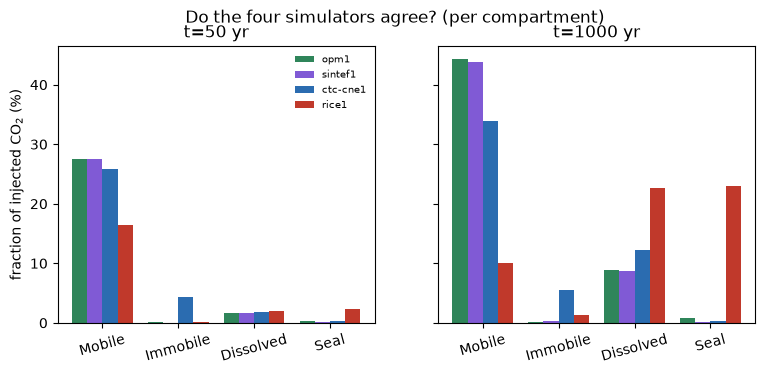

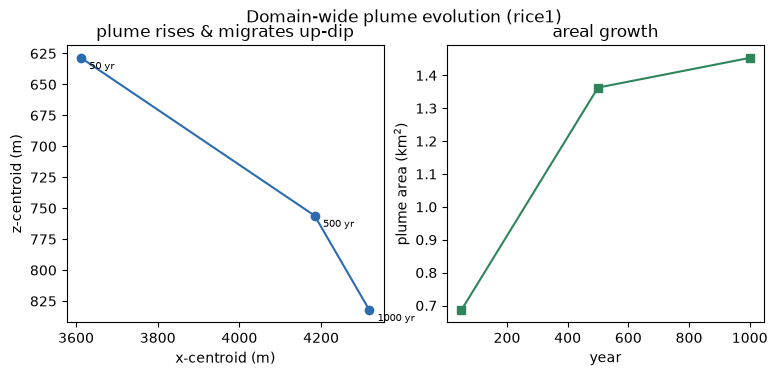

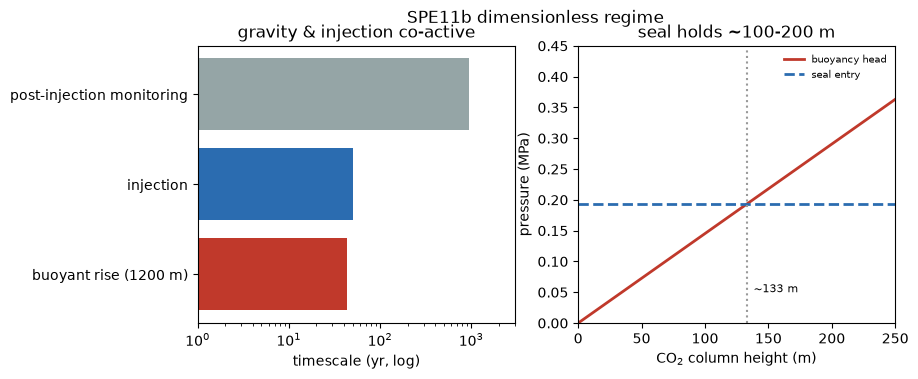

In [6]:
# Figure 1 - agreement
inv_yr = {50:{}, 1000:{}}
for yr in (50, 1000):
    for k in ('mobile','immobile','dissolved','seal'):
        inv_yr[yr][k] = {s: comp(at(sims[s], T_TARGET[yr]))[k]/TOTAL_INJECTED*100 for s in sims}
comps = [('mobile','Mobile'),('immobile','Immobile'),('dissolved','Dissolved'),('seal','Seal')]
SCOL = {'rice1':'#c0392b','ctc-cne1':'#2b6cb0','opm1':'#2f855a','sintef1':'#805ad5'}
fig, ax = plt.subplots(1,2,figsize=(9,3.6),sharey=True)
for axi, yr in zip(ax, (50,1000)):
    x = np.arange(len(comps)); w=0.2
    for i,s in enumerate(sims):
        axi.bar(x+(i-1.5)*w, [inv_yr[yr][k][s] for k,_ in comps], w, color=SCOL[s], label=s)
    axi.set_xticks(x); axi.set_xticklabels([c[1] for c in comps], rotation=15)
    axi.set_title(f"t={yr} yr")
ax[0].set_ylabel("fraction of injected CO$_2$ (%)")
ax[0].legend(frameon=False, fontsize=7)
fig.suptitle("Do the four simulators agree? (per compartment)")
plt.show()

# Figure 2 - plume trajectory + area
pyr = [r[0] for r in rows]; px = [r[1] for r in rows]; pz = [r[2] for r in rows]; pa=[r[3] for r in rows]
fig,(a1,a2)=plt.subplots(1,2,figsize=(9,3.6))
a1.plot(px,pz,'o-',color='#2b6cb0'); a1.invert_yaxis()
for xt,zt,t in zip(px,pz,pyr): a1.annotate(f"{t} yr",(xt,zt),xytext=(6,-8),textcoords='offset points',fontsize=7)
a1.set_xlabel("x-centroid (m)"); a1.set_ylabel("z-centroid (m)"); a1.set_title("plume rises & migrates up-dip")
a2.plot(pyr,pa,'s-',color='#2f855a'); a2.set_xlabel("year"); a2.set_ylabel("plume area (km$^2$)"); a2.set_title("areal growth")
fig.suptitle("Domain-wide plume evolution (rice1)")
plt.show()

# Figure 3 - timescales + seal balance
fig,(b1,b2)=plt.subplots(1,2,figsize=(9,3.6))
ts_labels = ["buoyant rise (1200 m)", "injection", "post-injection monitoring"]
ts_vals = [t_grav/(365*86400), t_inj/(365*86400), t_post/(365*86400)]
b1.barh(ts_labels, ts_vals, color=['#c0392b','#2b6cb0','#95a5a6']); b1.set_xscale('log'); b1.set_xlim(1,3000)
b1.set_xlabel("timescale (yr, log)"); b1.set_title("gravity & injection co-active")
hh = np.linspace(0,250,100)
b2.plot(hh, DELTA_RHO*G*hh/1e6, color='#c0392b', lw=2, label='buoyancy head')
b2.axhline(p_entry/1e6, color='#2b6cb0', ls='--', lw=2, label='seal entry')
b2.axvline(h_break, color='0.6', ls=':'); b2.text(h_break+5,0.05,f"~{h_break:.0f} m",fontsize=8)
b2.set_xlabel("CO$_2$ column height (m)"); b2.set_ylabel("pressure (MPa)"); b2.set_xlim(0,250); b2.set_ylim(0,0.45)
b2.legend(frameon=False, fontsize=7); b2.set_title("seal holds ~100-200 m")
fig.suptitle("SPE11b dimensionless regime")
plt.show()

## Takeaway

* SPE11b is a **transitional gravity–viscous** system — this is why residual trapping is negligible at shut-in (continuous drainage) and why long-term fate is gravity-driven.
* The benchmark's four simulators **converge on plume mobility but not on long-term trapping** (1–2 orders of magnitude spread on residual & structural trapping, one outlier: rice1).
* Therefore SPE11b can validate **migration**, not **trapping** — and any validation claim should be made compartment-wise, from the spatial maps, with the ensemble spread reported as uncertainty.

Everything above is reproducible: rerun any cell, or clone the repo and run the `scripts/` modules. Data © 11th SPE CSP (Nordbotten et al. 2024, https://spe.org/csp/spe11).